<a href="https://colab.research.google.com/github/wjarret/Thesis_Code_Book/blob/main/snRNA%20data%20analysis/Aim%201/Multivariate_Analysis_of_snRNA_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Overview

Scientific question: Given the variance seen in previous U snRNA data, can we use multivariate analysis to compare the variance between samples.

Samples: All U snRNA sequencing data to date.

Expeirmental design: To set up this eperiment, I will be isolating all possible 16 nt combinations of snRNA data by creating a sliding window.

Expected outcome:  This experiment will group together all U snRNA data, proving that the Sm binding region is unique and identifiable in a larger dataset.

In this document, I will be creating a dataset consisting of 16 nucleotide chunks of snRNA RNP-MaP data. To do this, starting at the begining of every seqeunce, for every 16 nucloetides, create its own data frame consisting of all RNP-MaP data, labeled with a unique name. After each window is created, dimensionality reduction will be used to assess variation. Steps:

> Create function that uses a sliding window to get all possible 16 window combinations and label each one based off of seqeunce identity.
>
> Apply function across all datasets.
>
> Run Principle Component Analysis (PCA) on all data and define inclusive principle components
>
> Due to increased data complexity, Uniform Manifold Approximation and Projection (UMAP) will be used.


##Loading in Librarys

In [ ]:
#Librarys
import os
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from google.colab import data_table
data_table.enable_dataframe_formatter()
from matplotlib import pyplot as plt
import seaborn as sns
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)
!pip install scikit_posthocs
import scikit_posthocs as sp
!pip install itables
import itables
from itables import init_notebook_mode
init_notebook_mode()

#Directory
PATH = '/content/drive/My Drive/Data/RNP_MaP_CSVs'
os.chdir(PATH)
os.listdir()

Mounted at /content/drive
shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 4, in <module>
    from pip._internal.cli.main import main
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main.py", line 11, in <module>
    from pip._internal.cli.autocompletion import autocomplete
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/autocompletion.py", line 10, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main_parser.py", line 9, in <module>
    from pip._internal.build_env import get_runnable_pip
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/build_env.py", line 19, in <module>
    

['HeLa-U1_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U5_DMSO_aq_SDA_int_20260129_U5B_profile_RESULTS.csv',
 'HeLa-U5_DMSO_aq_SDA_int_20260129_U5A_profile_RESULTS.csv',
 'HeLa-U4atac_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U4_DMSO_aq_SDA_int_20260129_U4-2_profile_RESULTS.csv',
 'HeLa-U4_DMSO_aq_SDA_int_20260129_U4-1_profile_RESULTS.csv',
 'HeLa-U12_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U11_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv',
 'HeLa-U1_DMSO_aq_SDA_int_11092024_ASV1_profile_RESULTS.csv',
 'HeLa-U2_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv',
 'HeLa-U11_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv',
 'HeLa-U12_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv',
 'HeLa-U1_DMSO_aq_SDA_int_20250525_ASV1_profile_RESULTS.csv',
 'HeLa-U1_DMSO_aq_SDA_int_20250707_ASV2_profile_RESULTS.csv',
 'HeLa-U11_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv',
 'HeLa-U12_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv',
 'HeLa

In [ ]:
# !pip install black[jupyter]
# !black /content/drive/MyDrive/Colab\ Code/04092026_creating_sliding_window.ipynb


## Loading in snRNA Data Frames

In [ ]:
#20260129
U1_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U11_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U11_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
# U12_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U12_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U4_1_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U4_DMSO_aq_SDA_int_20260129_U4-1_profile_RESULTS.csv')
U4_2_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U4_DMSO_aq_SDA_int_20260129_U4-2_profile_RESULTS.csv')
U4_atac_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U4atac_DMSO_aq_SDA_int_20260129_ASV1_profile_RESULTS.csv')
U5A_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U5_DMSO_aq_SDA_int_20260129_U5A_profile_RESULTS.csv')
U5B_DMSO_aq_SDA_int_20260129 = pd.read_csv('HeLa-U5_DMSO_aq_SDA_int_20260129_U5B_profile_RESULTS.csv')
#07/07/2025
U1_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_20250707_ASV2_profile_RESULTS.csv')
U2_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U2_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv')
U11_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U11_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv')
U12_DMSO_aq_SDA_int_20250707 = pd.read_csv('HeLa-U12_DMSO_aq_SDA_int_20250707_ASV1_profile_RESULTS.csv')
#05/05/2025
U1_DMSO_aq_SDA_int_20250525 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_20250525_ASV1_profile_RESULTS.csv')
#11/09/24
U1_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U1_DMSO_aq_SDA_int_11092024_ASV1_profile_RESULTS.csv')
U2_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U2_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv')
U11_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U11_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv')
U12_DMSO_aq_SDA_int_11092024 = pd.read_csv('HeLa-U12_DMSO_aq_SDA_int_110924_ASV1_profile_RESULTS.csv')

print(len(U11_DMSO_aq_SDA_int_11092024))

#Data Dictionary

D_D = {
    'U1.1':  U1_DMSO_aq_SDA_int_11092024,
    'U1.2':  U1_DMSO_aq_SDA_int_20250525,
    'U1.3':  U1_DMSO_aq_SDA_int_20250707,
    'U1.4':  U1_DMSO_aq_SDA_int_20260129,
    'U2.1':  U2_DMSO_aq_SDA_int_11092024,
    'U2.2':  U2_DMSO_aq_SDA_int_20250707,
    'U11.1': U11_DMSO_aq_SDA_int_11092024,
    'U11.2': U11_DMSO_aq_SDA_int_20250707,
    'U11.3': U11_DMSO_aq_SDA_int_20260129,
    'U12.1': U12_DMSO_aq_SDA_int_11092024,
    'U12.2': U12_DMSO_aq_SDA_int_20250707,
    # 'U12.3': U12_DMSO_aq_SDA_int_20260129,
    'U4-1': U4_1_DMSO_aq_SDA_int_20260129,
    'U4-2': U4_2_DMSO_aq_SDA_int_20260129,
    'U4atac': U4_atac_DMSO_aq_SDA_int_20260129,
    'U5A': U5A_DMSO_aq_SDA_int_20260129,
    'U5B': U5B_DMSO_aq_SDA_int_20260129
}



128


## Creating Function

In [ ]:
def sliding_window(data,window_size,step):
  d = {}
  for key, df in data.items():
    n = len(df)
    for i in range(0,n-window_size+1,step):
      window = df.iloc[i:window_size+i].reset_index(drop=True)
      identity = f'{key}_{i}:{window_size+i}'
      d[identity] = window
  return d


In [ ]:
window = sliding_window(D_D,24,1)


window.keys()

dict_keys(['U1.1_0:24', 'U1.1_1:25', 'U1.1_2:26', 'U1.1_3:27', 'U1.1_4:28', 'U1.1_5:29', 'U1.1_6:30', 'U1.1_7:31', 'U1.1_8:32', 'U1.1_9:33', 'U1.1_10:34', 'U1.1_11:35', 'U1.1_12:36', 'U1.1_13:37', 'U1.1_14:38', 'U1.1_15:39', 'U1.1_16:40', 'U1.1_17:41', 'U1.1_18:42', 'U1.1_19:43', 'U1.1_20:44', 'U1.1_21:45', 'U1.1_22:46', 'U1.1_23:47', 'U1.1_24:48', 'U1.1_25:49', 'U1.1_26:50', 'U1.1_27:51', 'U1.1_28:52', 'U1.1_29:53', 'U1.1_30:54', 'U1.1_31:55', 'U1.1_32:56', 'U1.1_33:57', 'U1.1_34:58', 'U1.1_35:59', 'U1.1_36:60', 'U1.1_37:61', 'U1.1_38:62', 'U1.1_39:63', 'U1.1_40:64', 'U1.1_41:65', 'U1.1_42:66', 'U1.1_43:67', 'U1.1_44:68', 'U1.1_45:69', 'U1.1_46:70', 'U1.1_47:71', 'U1.1_48:72', 'U1.1_49:73', 'U1.1_50:74', 'U1.1_51:75', 'U1.1_52:76', 'U1.1_53:77', 'U1.1_54:78', 'U1.1_55:79', 'U1.1_56:80', 'U1.1_57:81', 'U1.1_58:82', 'U1.1_59:83', 'U1.1_60:84', 'U1.1_61:85', 'U1.1_62:86', 'U1.1_63:87', 'U1.1_64:88', 'U1.1_65:89', 'U1.1_66:90', 'U1.1_67:91', 'U1.1_68:92', 'U1.1_69:93', 'U1.1_70:94', 'U1.1

## Normality Analysis

> In this section, we will analyze the normality of both, the sliding window samples as well as the full snRNA seqeunces.

> First, I will be performing a shapiro-wilks test followed by a Q-Q plot

##Shapiro-Wilks test

In [ ]:
for sample_name, df in D_D.items():
  df['Norm_Score'].fillna(0, inplace=True)

from scipy.stats import shapiro

for sample_name, df in D_D.items():
  shapiro_wilks_test = shapiro(df['Norm_Score'])
  print(f'\nSample {sample_name}')
  print(shapiro_wilks_test)



Sample U1.1
ShapiroResult(statistic=np.float64(0.6456904493873983), pvalue=np.float64(2.68577297686546e-18))

Sample U1.2
ShapiroResult(statistic=np.float64(0.5769416303561523), pvalue=np.float64(8.257304056629811e-20))

Sample U1.3
ShapiroResult(statistic=np.float64(0.6344323765822517), pvalue=np.float64(1.4354926779900728e-18))

Sample U1.4
ShapiroResult(statistic=np.float64(0.5751820781161799), pvalue=np.float64(1.1429316500889337e-19))

Sample U2.1
ShapiroResult(statistic=np.float64(0.667438794179618), pvalue=np.float64(5.159364893450278e-19))

Sample U2.2
ShapiroResult(statistic=np.float64(0.6870225556919609), pvalue=np.float64(1.774397513224268e-18))

Sample U11.1
ShapiroResult(statistic=np.float64(0.6098569582413439), pvalue=np.float64(6.504116033045506e-17))

Sample U11.2
ShapiroResult(statistic=np.float64(0.6502663042989522), pvalue=np.float64(4.966490079695856e-16))

Sample U11.3
ShapiroResult(statistic=np.float64(0.7069153575356093), pvalue=np.float64(6.709476208989215e-15)

/tmp/ipykernel_21895/2020666023.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Norm_Score'].fillna(0, inplace=True)


Results:
> Shapiro-Wilks test was performed on all snRNA seqeunces. Shapiro-Wilks test rejects the null hypothesis for all samples, signifying the data significantly departs from normality.

###Q-Q Plot

U1.1


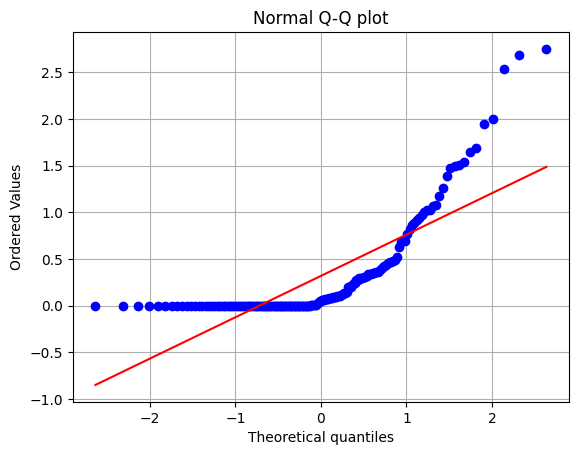

U1.2


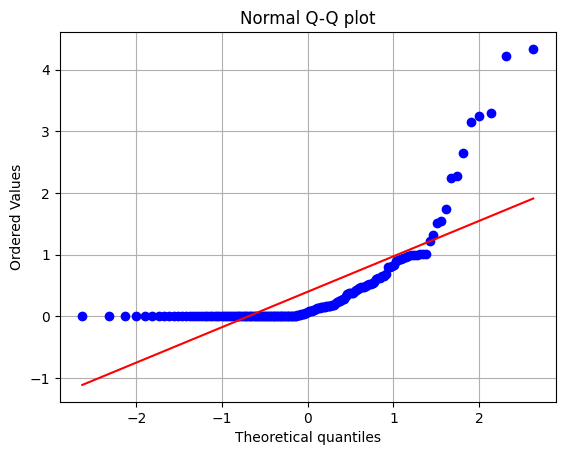

U1.3


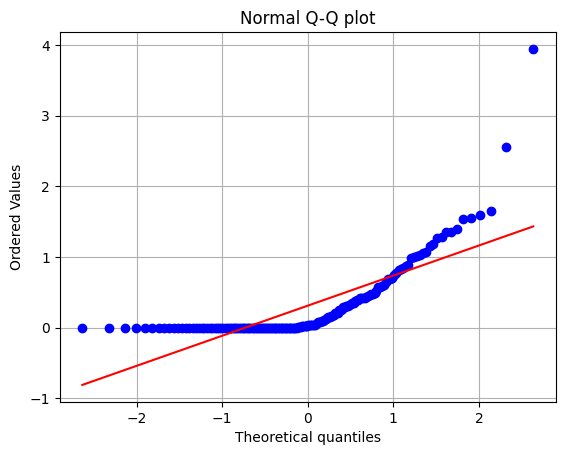

U1.4


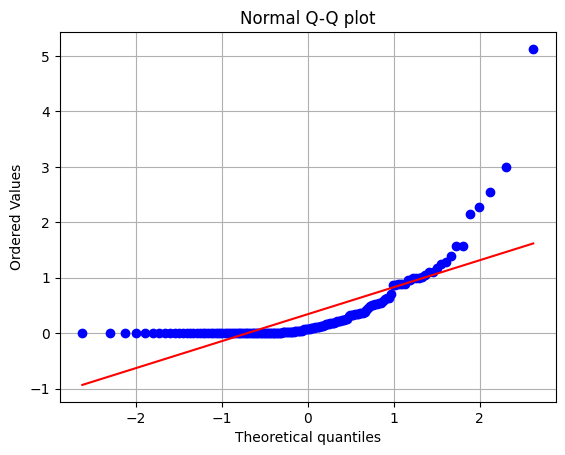

U2.1


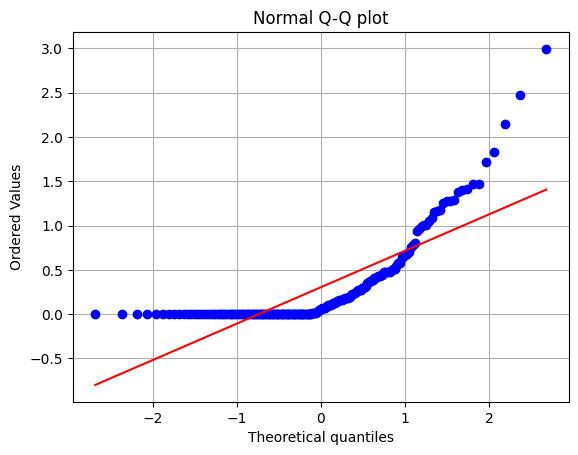

U2.2


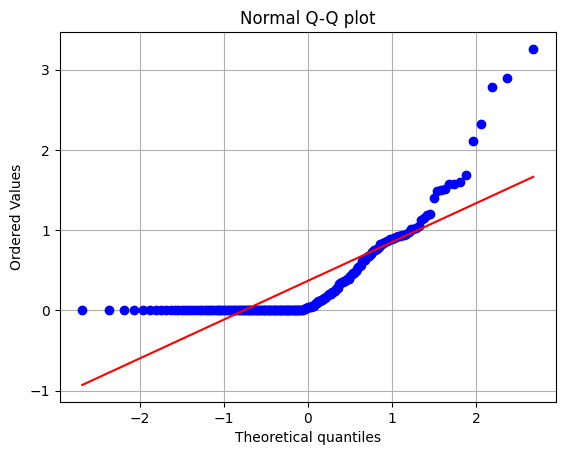

U11.1


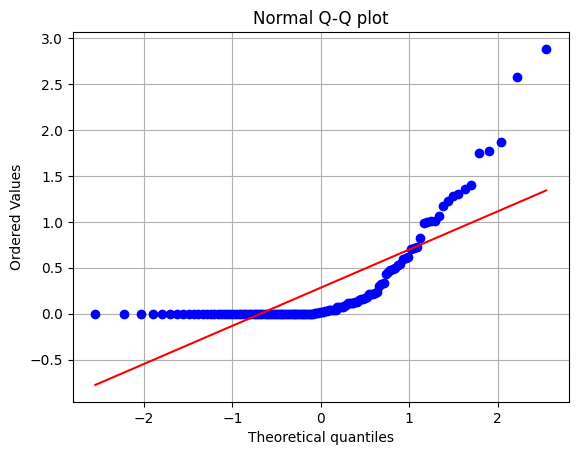

U11.2


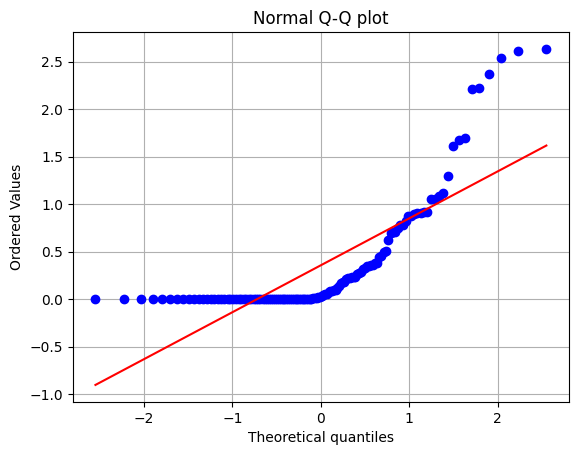

U11.3


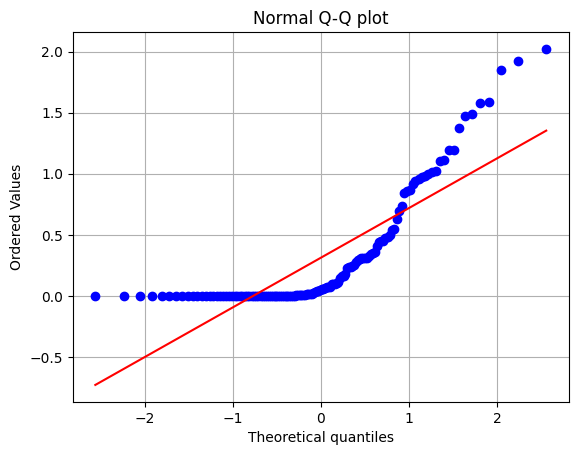

U12.1


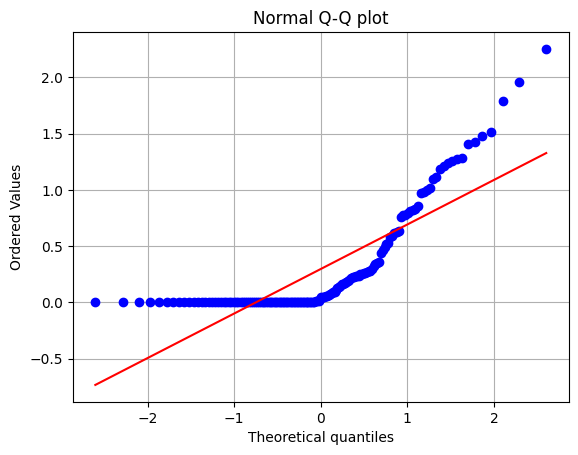

U12.2


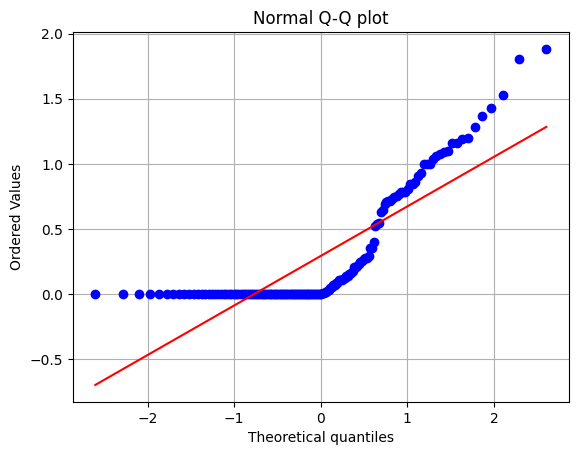

U4-1


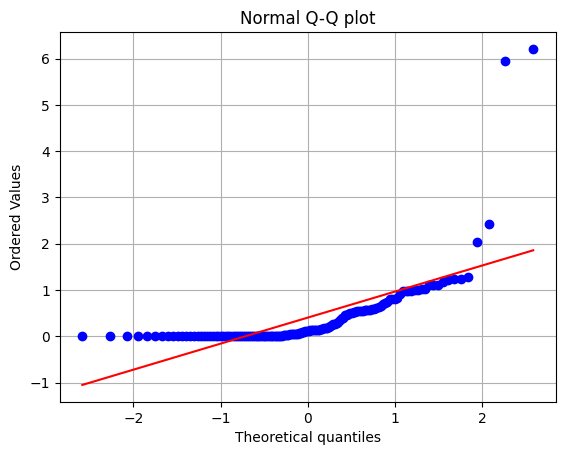

U4-2


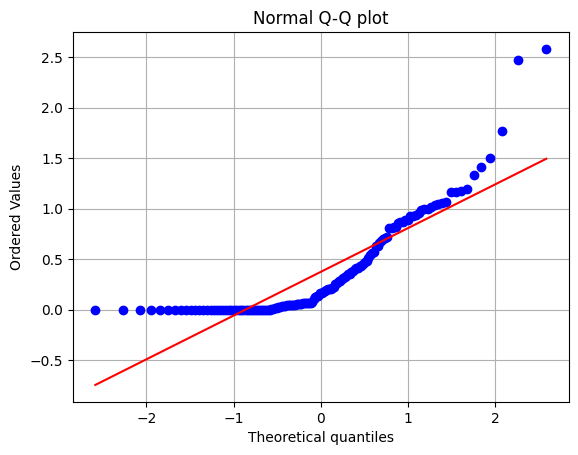

U4atac


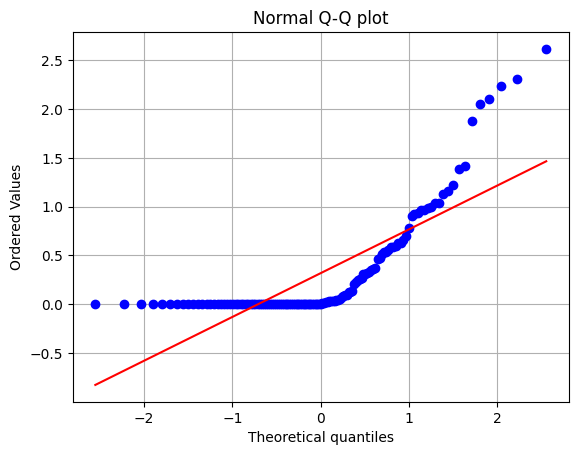

U5A


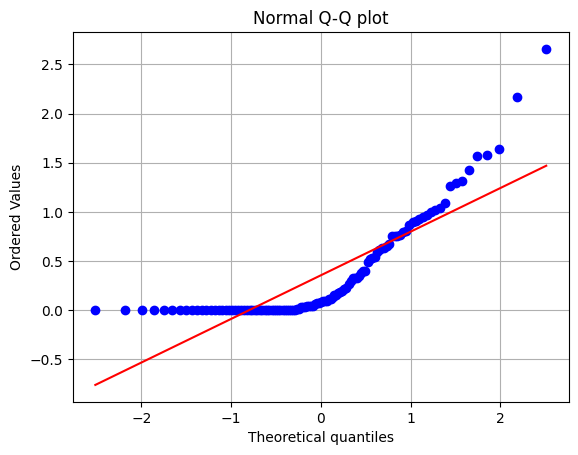

U5B


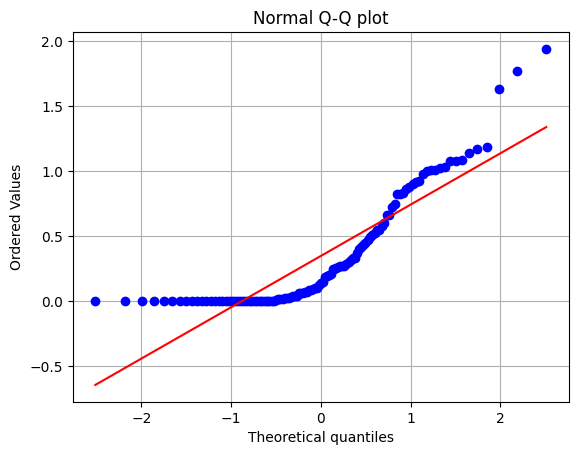

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Create Q-Q plot function
def Plop(data):
  numeric_data = data['Norm_Score'].fillna(0)
  stats.probplot(numeric_data, dist="norm", plot=plt)
  plt.title('Normal Q-Q plot')
  plt.xlabel('Theoretical quantiles')
  plt.ylabel('Ordered Values')
  plt.grid(True)
  plt.show()

for name, df in D_D.items():
    print(f"{name}")
    Plop(df)



##Results:

> The results of the Q-Q plot shows simliar results to the Shapiro-Wilks test. The data do not fit to the line, representing a normal distribution, indicating the data deviates from a normal distribution.

## Kruskal-Wallis and Dunn's test

Wanting to compare the variacne of profiles, the data does not fit the assumptions required to perorm a multivariate ANOVA (MANOVA). So, I will be perfroming a Kruskal-Wallis analysis to determine how the snRNA seqeunces vary as well as how the sliding windows vary. I will perform a Dunn's test for Post-hoc analysis.

In [ ]:
#Global distribution of snRNA
def krillin(data,p_adjsutment):
    Goku = [df['Norm_Score'].fillna(0).values for df in data.values()]
    stat, p = stats.kruskal(*Goku)
    Trunks = sp.posthoc_dunn(Goku, p_adjust=p_adjsutment)
    Gohan = f'H stat = {stat} and P-value = {p}'
    print(Gohan)
    print(Trunks < 0.05)
    return Gohan, Trunks

krillin(D_D,'fdr_BH')



H stat = 23.763552928475484 and P-value = 0.06921909816904678
       1      2      3      4      5      6      7      8      9      10  \
1   False  False  False  False  False  False  False  False  False  False   
2   False  False  False  False  False  False  False  False  False  False   
3   False  False  False  False  False  False  False  False  False  False   
4   False  False  False  False  False  False  False  False  False  False   
5   False  False  False  False  False  False  False  False  False  False   
6   False  False  False  False  False  False  False  False  False  False   
7   False  False  False  False  False  False  False  False  False  False   
8   False  False  False  False  False  False  False  False  False  False   
9   False  False  False  False  False  False  False  False  False  False   
10  False  False  False  False  False  False  False  False  False  False   
11  False  False  False  False  False  False  False  False  False  False   
12  False  False  False  F

('H stat = 23.763552928475484 and P-value = 0.06921909816904678',
           1         2         3         4         5         6         7   \
 1   1.000000  0.838456  0.995028  0.674925  0.995028  0.838456  0.838456   
 2   0.838456  1.000000  0.838456  0.838456  0.838456  0.995028  0.674925   
 3   0.995028  0.838456  1.000000  0.674925  0.995028  0.838456  0.838456   
 4   0.674925  0.838456  0.674925  1.000000  0.674925  0.838456  0.500897   
 5   0.995028  0.838456  0.995028  0.674925  1.000000  0.838456  0.838456   
 6   0.838456  0.995028  0.838456  0.838456  0.838456  1.000000  0.674925   
 7   0.838456  0.674925  0.838456  0.500897  0.838456  0.674925  1.000000   
 8   0.903232  0.939507  0.903232  0.838456  0.903232  0.939507  0.803226   
 9   0.810768  0.903232  0.814008  0.919307  0.810768  0.903232  0.663361   
 10  0.990149  0.838456  0.990149  0.721233  0.990149  0.838456  0.838456   
 11  0.838456  0.771810  0.838456  0.545262  0.838456  0.759215  0.935459   
 12  0.500

Looking across all the snRNA seqeunces, there is no difference between the distributions of the samples.

In [ ]:
#Sm site analysis

#U1
Filtered_U1_11092024 = U1_DMSO_aq_SDA_int_11092024[['Norm_Score']].iloc[118:142]
Filtered_U1_20250525 = U1_DMSO_aq_SDA_int_20250525[['Norm_Score']].iloc[118:142]
Filtered_U1_20250707 = U1_DMSO_aq_SDA_int_20250707[['Norm_Score']].iloc[118:142]
Filtered_U1_20260129 = U1_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[114:138]

#U2
Filtered_U2_11092024 = U2_DMSO_aq_SDA_int_11092024[['Norm_Score']].iloc[90:114]
Filtered_U2_20250707 = U2_DMSO_aq_SDA_int_20250707[['Norm_Score']].iloc[90:114]

#U11
Filtered_U11_11092024 = U11_DMSO_aq_SDA_int_11092024[['Norm_Score']].iloc[80:104]
Filtered_U11_20250707 = U11_DMSO_aq_SDA_int_20250707[['Norm_Score']].iloc[80:104]
Filtered_U11_20260129 = U11_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[78:102]

#U12
Filtered_U12_11092024 = U12_DMSO_aq_SDA_int_11092024[['Norm_Score']].iloc[66:90]
Filtered_U12_20250707 = U12_DMSO_aq_SDA_int_20250707[['Norm_Score']].iloc[66:90]
# Filtered_U12_20260129 = U12_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[64:88]

#U4
Filtered_U4_1_20260129   = U4_1_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[110:134]
Filtered_U4_2_20260129   = U4_2_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[110:134]
Filtered_U4_atac_20260129 = U4_atac_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[97:121]

#U5
Filtered_U5A_20260129 = U5A_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[80:104]
Filtered_U5B_20260129 = U5B_DMSO_aq_SDA_int_20260129[['Norm_Score']].iloc[80:104]

#making a dicionary of the filtered dataframes for PCA
Llama = {
    'U1.1':  Filtered_U1_11092024,
    'U1.2':  Filtered_U1_20250525,
    'U1.3':  Filtered_U1_20250707,
    'U1.4':  Filtered_U1_20260129,
    'U2.1':  Filtered_U2_11092024,
    'U2.2':  Filtered_U2_20250707,
    'U11.1': Filtered_U11_11092024,
    'U11.2': Filtered_U11_20250707,
    'U11.3': Filtered_U11_20260129,
    'U12.1': Filtered_U12_11092024,
    'U12.2': Filtered_U12_20250707,
    # 'U12.3': Filtered_U12_20260129,
    'U4-1': Filtered_U4_1_20260129,
    'U4-2': Filtered_U4_2_20260129,
    'U4atac': Filtered_U4_atac_20260129,
    'U5A': Filtered_U5A_20260129,
    'U5B': Filtered_U5B_20260129
}

In [ ]:
#sliding window analysis
def vegeta(data, p_adjustment):
    group_names = data.columns.tolist()
    Goku = [data[col].values for col in group_names]
    stat, p = stats.kruskal(*Goku)
    Trunks = sp.posthoc_dunn(Goku, p_adjust=p_adjustment)
    Trunks.index = group_names
    Trunks.columns = group_names
    sig_mask = Trunks < 0.05
    sig_long = Trunks.where(sig_mask).stack().dropna()
    return data.var()  # ← returns a Series of variance per column

d = {}
for key, df in window.items():
    df = df[['Norm_Score']]
    identifier = f'{key}'
    d[identifier] = df
dragonball = pd.concat(d)
dragonball = dragonball.reset_index()
dragonball = dragonball.pivot_table(index = 'level_1',values = 'Norm_Score', columns = 'level_0').fillna(0)
output = vegeta(dragonball, 'bonferroni')


KeyboardInterrupt: 

##Ranked Variance plot

In [ ]:
rank_data_frame = pd.DataFrame(output).reset_index()
rank_data_frame.columns = ["Sample","Measured Variance"]
# stacking = rank_data_frame.stack()
# stacking.index.names = ["Sample_1", "Sample_2"]
# corr_pairs = stacked.reset_index(name="Correlation")
Ranks = rank_data_frame["Measured Variance"].rank(method = 'max')
rank_data_frame["Cumulative Frequency"] = Ranks*100/Ranks.max()
rank_data_frame
points_to_highlight = [
    'U1.1_118:142', 'U1.2_118:142', 'U1.3_118:142', 'U1.4_114:138',
    'U2.1_90:114', 'U2.2_90:114',
    'U11.1_80:104', 'U11.2_80:104', 'U11.3_78:102',
    'U12.1_66:90', 'U12.2_66:90', #'U12.3_64:88',
    'U4-1_110:134', 'U4-2_110:134', 'U4atac_97:121',
    'U5A_80:104', 'U5B_80:104'
]

fig, ax = plt.subplots()
ax.scatter(rank_data_frame["Measured Variance"], rank_data_frame["Cumulative Frequency"], alpha=0.4, s=20)

# for _, row in rank_data_frame.iterrows():
#     if row["Sample"] in points_to_highlight:
#         ax.annotate(
#             row["Sample"],
#             (row["Measured Variance"], row["Cumulative Frequency"]),
#             textcoords="offset points",
#             xytext=(5, 5)
#         )
ph = rank_data_frame[
    rank_data_frame["Sample"].isin(points_to_highlight)
]

ax.scatter(ph["Measured Variance"], ph["Cumulative Frequency"],
           color='red', s=40, zorder=5)
plt.xlabel("Measured Variance")
plt.ylabel("Cumulative Frequency")
plt.show()

In [ ]:
# rank_data_frame

filtered_rank_data_frame = rank_data_frame[
    rank_data_frame["Sample"].isin(points_to_highlight)
].reset_index(drop=True)
# len(filtered_rank_data_frame)/len(rank_data_frame)*100
filtered_rank_data_frame
# filtered_rank_data_frame[(filtered_rank_data_frame['measured'] <= 1) & (highlight_pairs['Correlation'] >= -0.5)]

## Cumulative distribution plot of pearson correlations

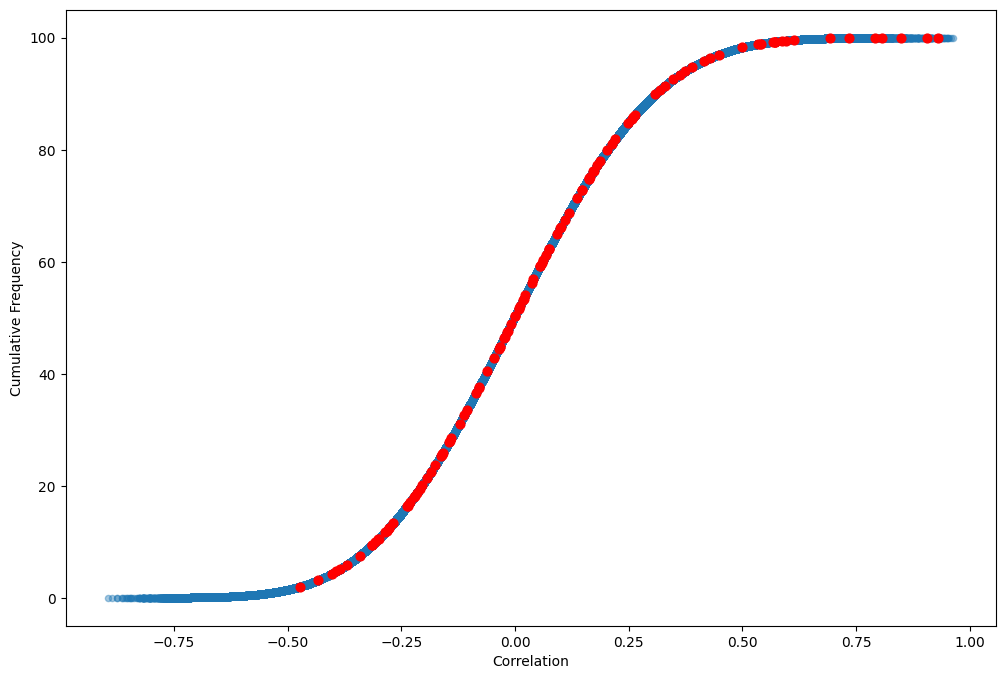

In [ ]:
crank = dragonball.corr(method = 'spearman')

mask = np.triu(np.ones(crank.shape), k=1).astype(bool)
stacked = crank.where(mask).stack()
stacked.index.names = ["Sample_1", "Sample_2"]
corr_pairs = stacked.reset_index(name="Correlation")
Ranks = corr_pairs["Correlation"].rank(method = 'max')
corr_pairs["Cumulative Frequency"] = Ranks*100/Ranks.max()
corr_pairs
points_to_highlight = [
    'U1.1_118:142', 'U1.2_118:142', 'U1.3_118:142', 'U1.4_114:138',
    'U2.1_90:114', 'U2.2_90:114',
    'U11.1_80:104', 'U11.2_80:104', 'U11.3_78:102',
    'U12.1_66:90', 'U12.2_66:90', #'U12.3_64:88',
    'U4-1_110:134', 'U4-2_110:134', 'U4atac_97:121',
    'U5A_80:104', 'U5B_80:104'
]
# Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(corr_pairs["Correlation"], corr_pairs["Cumulative Frequency"], alpha=0.4, s=20)

# filter to pairs where both samples are in your highlight list
highlight_pairs = corr_pairs[
    corr_pairs["Sample_1"].isin(points_to_highlight) &
    corr_pairs["Sample_2"].isin(points_to_highlight)
]

# plot highlighted points in different color
ax.scatter(highlight_pairs["Correlation"], highlight_pairs["Cumulative Frequency"],
           color='red', s=40, zorder=5)

plt.xlabel("Correlation")
plt.ylabel("Cumulative Frequency")
plt.show()

In [ ]:
highlight_pairs = corr_pairs[corr_pairs["Sample_1"].isin(points_to_highlight) & corr_pairs["Sample_2"].isin(points_to_highlight)].reset_index(drop=True)

highlight_pairs[(highlight_pairs['Correlation'] <= 1) & (highlight_pairs['Correlation'] >= -1)]
len(highlight_pairs)
min_highlight_freq = highlight_pairs["Cumulative Frequency"].min()
max_highlight_freq = highlight_pairs["Cumulative Frequency"].max()

print(f"{min_highlight_freq}% of all pairs fall below the lowest highlighted pair")
print(f"{max_highlight_freq}% of all pairs fall above the highest highlighted pair")




1.9750840679010941% of all pairs fall below the lowest highlighted pair
99.99848412499905% of all pairs fall above the highest highlighted pair


### Results

> Looking at the data output, the variance appears to be driven by U4 snRNA variation. The results from the kruskal-wallis analysis provided a P-value < 0.05. When performing Dunn's test posthoc with a bonfferroni False discovery rate (FDR) correction, evidence of differences in variance  is driven by U4 snRNA. Overall, the Sm-site seqeuence variance is not statistically different from non-Sm sites.

### **Discussion**

>

###Future Direction
>